# Manufacturing Materials and Spending Analysis

This project analyzes manufacturing purchasing data to identify spending trends,
supplier patterns, product-category performance, and potential operational risks.

## Project Objective

The objective of this analysis is to clean and explore manufacturing purchasing
data, identify meaningful spending patterns, and develop business recommendations
that could improve purchasing and supply-chain decision-making.

## 1. Importing Libraries

In [1]:
from pathlib import Path
import pandas as pd

files = list(Path.cwd().parent.rglob("*.csv"))
files

[WindowsPath('c:/Users/louis/OneDrive/Documents/manufacturing material analysis/data/raw/Global Furnace Requirments Dataset (1).csv')]

## 2. Loading and Reviewing the Data

In [2]:
csv_path = files[0]

df = pd.read_csv(csv_path, encoding="cp1252")

In [3]:
df.head()

,Project ID,Sr No.,Item Name,Item Category,Quantity,UOM,Rate ($),Amount ($),Weight (kg),Month,Year,Company Name,City,Country
0,AG-SEP24,1,CABLE TRAY,Electrical,19.0,No.,$14.00,$271.00,200.0,Augest,2024,Foundary Port Sudan,Khartoum,Sudan
1,AG-SEP24,2,END CLAMP,Electrical,25.0,No.,$0.16,$4.00,250.0,Augest,2024,Foundary Port Sudan,Khartoum,Sudan
2,AG-SEP24,3,MIDDLE CLAMP,Electrical,435.0,No.,$0.20,$85.00,4350.0,Augest,2024,Foundary Port Sudan,Khartoum,Sudan
3,AG-SEP24,4,Activated Carbon,Furnace Material,1.0,Bag,$29.00,$29.00,25.0,Augest,2024,Foundary Port Sudan,Khartoum,Sudan
4,AG-SEP24,5,Bentonide Powder,Furnace Material,1.0,Ton,$75.00,$75.00,2000.0,Augest,2024,Foundary Port Sudan,Khartoum,Sudan


In [4]:
df.columns = df.columns.str.strip()

In [5]:
df.columns

Index(['Project ID', 'Sr No.', 'Item Name', 'Item Category', 'Quantity', 'UOM',
       'Rate ($)', 'Amount ($)', 'Weight (kg)', 'Month', 'Year',
       'Company Name', 'City', 'Country'],
      dtype='str')

In [6]:
df["Item Category"].value_counts()

Item Category
Raw Material        253
Mechanical           68
Furnace Material     44
L&T                  22
Electrical           15
Solar Material       12
Cable                12
Account              12
Meter                11
Paktharm Matrial      5
L&T                   3
Name: count, dtype: int64

In [7]:
df["Company Name"].value_counts()

Company Name
Foundary Port Sudan           122
Ghazi Abbas Steel Mills       111
Ali Global Trading Company     63
Shalimar Steels                56
PakArab Steel Factory          36
Arfan Kosti Steel Factory      33
Dynamic Steels                 23
Paktherm Pvt. Ltd.             13
Name: count, dtype: int64

In [8]:
df['Country'].value_counts()

Country
Sudan       358
Pakistan     99
Name: count, dtype: int64

In [9]:
df['Month'].value_counts()

Month
January      108
June          74
May           55
Augest        54
December      44
April         24
September     21
February      21
November      20
March         19
July          17
Name: count, dtype: int64

## 3. Data Cleaning

In [10]:
clean_amount = (
    df["Amount ($)"]
      .str.replace("$", "", regex=False)
      .str.replace(",", "", regex=False)
)

pd.to_numeric(clean_amount, errors="coerce")

0      271.0
1        4.0
2       85.0
3       29.0
4       75.0
       ...  
452    536.0
453     12.0
454     17.0
455    893.0
456      NaN
Name: Amount ($), Length: 457, dtype: float64

In [11]:
bad_rows = df[pd.to_numeric(clean_amount, errors="coerce").isna()]
bad_rows[["Amount ($)"]]

,Amount ($)
227,$-
318,$-
357,NaN
358,NaN
359,NaN
360,NaN
361,NaN
362,NaN
363,NaN
364,NaN


## 4. Exploratory Data Analysis

In [12]:
df.groupby('Item Category')["Amount ($)"].sum()

Item Category
Account              $3,750.00  $250.00  $7.00  $18.00  $71.00  $6...
Cable                $32.00  $295.00  $1,856.00  $48.00  $8.00  $1...
Electrical           $271.00  $4.00  $85.00  $35.00  $120.00  $5,0...
Furnace Material     $29.00  $75.00  $141.00  $214.00  $57.00  $16...
L&T                                       $252.00  $7,857.00  $11.00 
L&T                  $43.00  $3,571.00  $179.00  $30.00  $16.00  $...
Mechanical           $30.00  $125.00  $1,301.00  $161.00  $214.00 ...
Meter                $25.00  $25.00  $4.00  $5.00  $21.00  $7.00  ...
Paktharm Matrial          $71.00  $89.00  $18.00  $1,071.00  $143.00 
Raw Material         $59.00  $23.00  $8.00  $13.00  $2,321.00  $71...
Solar Material       $183.00  $1,232.00  $15,930.00  $500.00  $446...
Name: Amount ($), dtype: str

In [13]:
clean_amount = (
    df["Amount ($)"]
      .str.replace("$", "", regex=False)
      .str.replace(",", "", regex=False)
      .str.replace("-", "0", regex=False)
)

df["Amount ($)"] = pd.to_numeric(clean_amount, errors="coerce")

In [14]:
df["Amount ($)"].dtype

dtype('float64')

In [15]:
df.groupby("Item Category")["Amount ($)"].sum().sort_values(ascending=False)

Item Category
Raw Material        54421.0
Mechanical          45884.0
Furnace Material    38027.0
Solar Material      19410.0
Electrical          11982.0
Account             10337.0
L&T                  8120.0
L&T                  5653.0
Cable                3280.0
Paktharm Matrial     1392.0
Meter                 144.0
Name: Amount ($), dtype: float64

In [16]:
df.nlargest(10, "Amount ($)")

,Project ID,Sr No.,Item Name,Item Category,Quantity,UOM,Rate ($),Amount ($),Weight (kg),Month,Year,Company Name,City,Country
8,AG-SEP24,9,Complete Furnace 200/300 kg,Furnace Material,1.0,NO.,"$16,071.00",16071.0,10.0,Augest,2024,Foundary Port Sudan,Khartoum,Sudan
53,AG-SEP24,54,SOLAR PLATE (Trina 590-Watt),Solar Material,216.0,No.,$74.00,15930.0,6000.0,Augest,2024,Foundary Port Sudan,Khartoum,Sudan
390,AG-FEB26,391,Container Freight,L&T,1.0,No.,"$7,857.00",7857.0,10.0,February,2026,PakArab Steel Factory,Khartoum,Sudan
218,AG-FEB26,219,Furnace 150 kg Single Crucible Complete,Furnace Material,1.0,No.,"$7,143.00",7143.0,500.0,December,2025,PakArab Steel Factory,Khartoum,Sudan
440,DS-JUN26,441,Moulding Box,Raw Material,6.0,No.,"$1,143.00",6857.0,250.0,June,2026,Dynamic Steels,Sheikhupura,Pakistan
201,AG-APR25,202,Pully 4 inch,Mechanical,1200.0,No.,$5.00,6000.0,12000.0,April,2025,Shalimar Steels,Soba,Sudan
259,AG-JAN25,260,Pully 4 inch,Mechanical,1200.0,No.,$5.00,6000.0,12000.0,January,2025,Ghazi Abbas Steel Mills,Kosti,Sudan
156,AG-JAN25,157,Electric moter 400 hp,Electrical,1.0,No.,"$5,000.00",5000.0,10.0,November,2024,Ghazi Abbas Steel Mills,Kosti,Sudan
236,AG-JAN25,237,Electric moter 400 hp,Electrical,1.0,No.,"$5,000.00",5000.0,10.0,January,2025,Arfan Kosti Steel Factory,Kosti,Sudan
385,AG-FEB26,386,Lath Machine 8 ft,Mechanical,2.0,Machine,"$2,500.00",5000.0,1000.0,November,2025,PakArab Steel Factory,Khartoum,Sudan


In [17]:
df.groupby("Company Name")["Amount ($)"].sum().sort_values(ascending=False)

Company Name
Foundary Port Sudan           58351.0
PakArab Steel Factory         49008.0
Ghazi Abbas Steel Mills       36073.0
Dynamic Steels                19194.0
Ali Global Trading Company    13596.0
Arfan Kosti Steel Factory     13062.0
Shalimar Steels                8777.0
Paktherm Pvt. Ltd.              589.0
Name: Amount ($), dtype: float64

In [18]:
df.groupby("Month")["Amount ($)"].sum().sort_values()

Month
March          286.0
May            460.0
July          2431.0
April         8367.0
September     9619.0
February     12392.0
November     22409.0
December     25428.0
June         35395.0
January      38038.0
Augest       43825.0
Name: Amount ($), dtype: float64

## 5. Visualizations

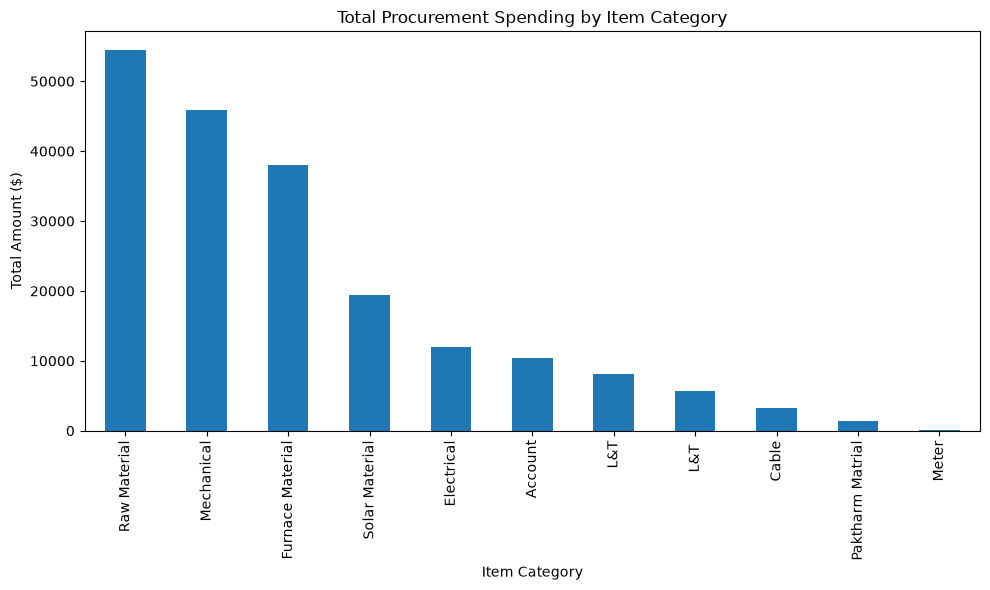

In [19]:
import matplotlib.pyplot as plt

category_totals = (
    df.groupby("Item Category")["Amount ($)"]
      .sum()
      .sort_values(ascending=False)
)

category_totals.plot(kind="bar", figsize=(10,6))

plt.title("Total Procurement Spending by Item Category")
plt.ylabel("Total Amount ($)")
plt.xlabel("Item Category")

plt.tight_layout()
plt.show()

Raw Material and Mechanical account for the largest share of procurement spending. This suggests that cost-saving initiatives focused on these categories could have the greatest financial impact.

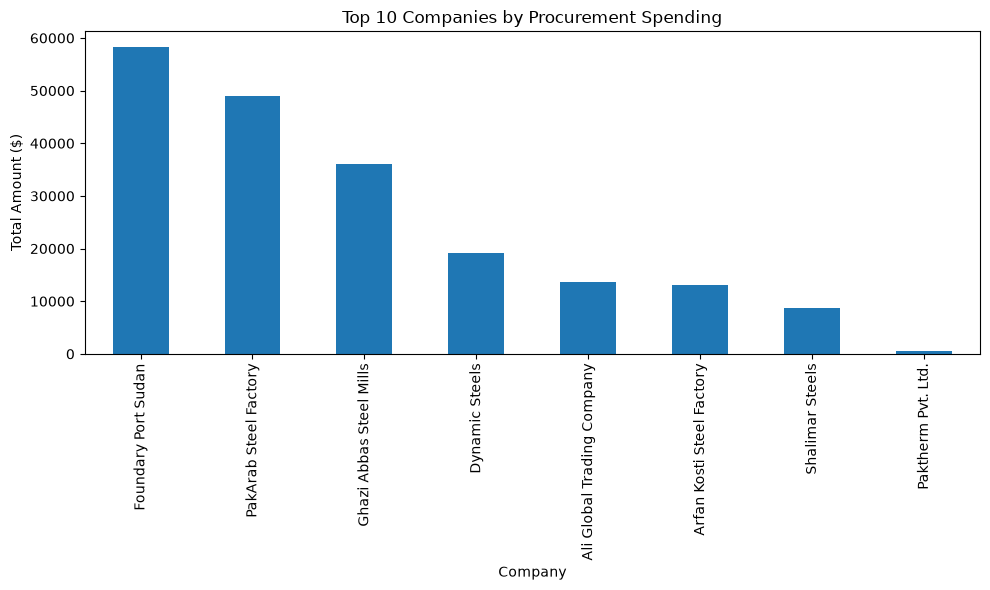

In [20]:
company_totals = (
    df.groupby("Company Name")["Amount ($)"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

company_totals.plot(kind="bar", figsize=(10,6))

plt.title("Top 10 Companies by Procurement Spending")
plt.xlabel("Company")
plt.ylabel("Total Amount ($)")

plt.tight_layout()
plt.show()

Foundry Port Sudan and Pakarab Steel Factory represent the highest procurement spending in this dataset, indicating that purchasing activity is concentrated among a small number of companies.

<Axes: xlabel='Company Name'>

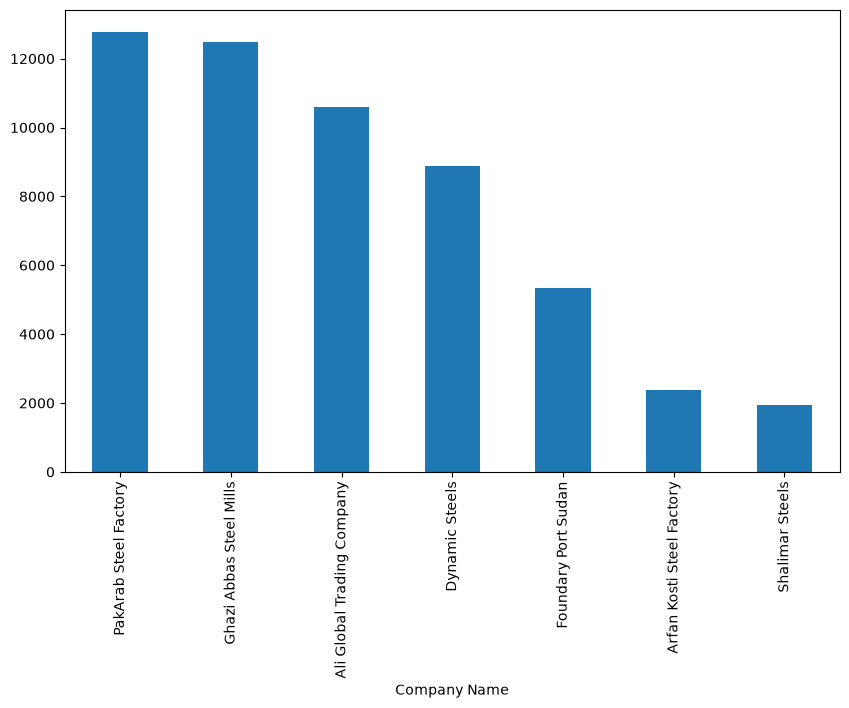

In [21]:
raw_materials_top_compaines = df[df["Item Category"] == "Raw Material"].groupby("Company Name")["Amount ($)"].sum().sort_values(ascending=False).head(10)
raw_materials_top_compaines.plot(kind="bar", figsize=(10,6))

In [22]:
df["Year"]

0      2024
1      2024
2      2024
3      2024
4      2024
       ... 
452    2026
453    2026
454    2026
455    2026
456    2026
Name: Year, Length: 457, dtype: int64

## Key Findings

- Raw Material had the highest total procurement spending at about $54,000. Mechanical was next at around $46,000, followed by Furnace Material at about $38,000.
- Most of the overall spending came from the top three item categories, which shows that procurement costs were concentrated in a smaller number of areas.
- Foundry Port Sudan had the highest total spending at about $58,000. PakArab Steel Factory was second at around $49,000, followed by Ghazi Abbas Steel Mills at about $36,000.
- There was a large difference between the highest-spending and lowest-spending companies, showing that purchasing activity was not evenly distributed.
- Some categories and companies had very little spending compared with the top groups, which may be worth looking into further.

## Business Recommendations

- Focus cost-saving efforts on Raw Material, Mechanical, and Furnace Material because these categories account for most of the spending.
- Review the highest-spending companies to see whether better pricing, volume discounts, or longer-term agreements could reduce costs.
- Track how much spending is concentrated with a small number of suppliers so the company does not become too dependent on one source.
- Look further into why spending differs so much between categories and companies, including order volume, unit cost, and purchase frequency.
- Create a recurring dashboard that tracks spending by category, company, and time period so changes and unusual patterns can be noticed earlier.

In [26]:
df.to_csv("../data/processed/procurement_clean.csv", index=False)

In [32]:
df.head()

,Project ID,Sr No.,Item Name,Item Category,Quantity,UOM,Rate ($),Amount ($),Weight (kg),Month,Year,Company Name,City,Country
0,AG-SEP24,1,CABLE TRAY,Electrical,19.0,No.,$14.00,271.0,200.0,Augest,2024,Foundary Port Sudan,Khartoum,Sudan
1,AG-SEP24,2,END CLAMP,Electrical,25.0,No.,$0.16,4.0,250.0,Augest,2024,Foundary Port Sudan,Khartoum,Sudan
2,AG-SEP24,3,MIDDLE CLAMP,Electrical,435.0,No.,$0.20,85.0,4350.0,Augest,2024,Foundary Port Sudan,Khartoum,Sudan
3,AG-SEP24,4,Activated Carbon,Furnace Material,1.0,Bag,$29.00,29.0,25.0,Augest,2024,Foundary Port Sudan,Khartoum,Sudan
4,AG-SEP24,5,Bentonide Powder,Furnace Material,1.0,Ton,$75.00,75.0,2000.0,Augest,2024,Foundary Port Sudan,Khartoum,Sudan


In [34]:
len(df)

457